In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("Cleaned_Retail_Store_Data.csv")

In [3]:
df.head()

,Unnamed: 0,Transaction ID,Customer ID,Category,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Item,Item_name,Year,Month
0,0,TXN_6867343,CUST_09,Patisserie,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,1,Item_10_PAT,Cinnamon Roll,2024,April
1,1,TXN_3731986,CUST_22,Milk Products,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,1,Item_17_MILK,Dairy Creamer,2023,July
2,2,TXN_9303719,CUST_02,Butchers,21.5,2.0,43.0,Credit Card,Online,2022-10-05,0,Item_12_BUT,Meatballs,2022,October
3,3,TXN_9458126,CUST_06,Beverages,27.5,9.0,247.5,Credit Card,Online,2022-05-07,1,Item_16_BEV,Herbal Tea,2022,May
4,4,TXN_4575373,CUST_05,Food,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,0,Item_6_FOOD,Salt,2022,October


In [4]:
df_new = pd.DataFrame()

df_new['date'] = pd.to_datetime(df['Transaction Date'])
df_new['amount'] = df['Total Spent']
df_new['type'] = 'income'  
df_new['category'] = df['Category']
df_new['payment_mode'] = df['Payment Method'].replace("Digital Wallet", "UPI")

# Sort and reset index
df_new = df_new.sort_values('date').reset_index(drop=True)

df_new.head()

,date,amount,type,category,payment_mode
0,2022-01-01,62.5,income,Milk Products,UPI
1,2022-01-01,75.0,income,Computers and electric accessories,Credit Card
2,2022-01-01,109.5,income,Food,Cash
3,2022-01-01,75.0,income,Computers and electric accessories,UPI
4,2022-01-01,77.5,income,Beverages,Credit Card


In [5]:
# Number of expense rows (30% of income data)
expense_rows = int(len(df_new) * 0.009)

expense_data = pd.DataFrame({
    'date': np.random.choice(df_new['date'], size=expense_rows),
    'amount': np.random.randint(500, 5000, size=expense_rows),
    'type': ['expense'] * expense_rows,
    'category': np.random.choice(
        ['rent', 'salary', 'utilities', 'inventory'], 
        size=expense_rows
    ),
    'payment_mode': np.random.choice(['UPI', 'Cash'], size=expense_rows)
})

In [6]:
df_combined = pd.concat([df_new, expense_data])

# Sort by date
df_combined = df_combined.sort_values('date').reset_index(drop=True)

In [7]:
initial_balance = 10000

balance = []
current_balance = initial_balance

for _, row in df_combined.iterrows():
    if row['type'] == 'income':
        current_balance += row['amount']
    else:
        current_balance -= row['amount']
    
    balance.append(current_balance)

df_combined['balance'] = balance

In [8]:
df_combined.loc[10, 'amount'] = 50000

In [9]:
# Structure
df_combined.head()

,date,amount,type,category,payment_mode,balance
0,2022-01-01,62.5,income,Milk Products,UPI,10062.5
1,2022-01-01,75.0,income,Computers and electric accessories,Credit Card,10137.5
2,2022-01-01,109.5,income,Food,Cash,10247.0
3,2022-01-01,75.0,income,Computers and electric accessories,UPI,10322.0
4,2022-01-01,77.5,income,Beverages,Credit Card,10399.5


In [10]:
# Count types
df_combined['type'].value_counts()

type
income     12575
expense      113
Name: count, dtype: int64

In [11]:
# Total income vs expense
df_combined.groupby('type')['amount'].sum()

type
expense     287152.0
income     1681666.5
Name: amount, dtype: float64

In [12]:
# Balance is not going negative too much
df_combined['balance'].tail()

12683    1354601.0
12684    1354671.0
12685    1354733.5
12686    1354752.5
12687    1354819.5
Name: balance, dtype: float64

In [13]:
df_combined

,date,amount,type,category,payment_mode,balance
0,2022-01-01,62.5,income,Milk Products,UPI,10062.5
1,2022-01-01,75.0,income,Computers and electric accessories,Credit Card,10137.5
2,2022-01-01,109.5,income,Food,Cash,10247.0
3,2022-01-01,75.0,income,Computers and electric accessories,UPI,10322.0
4,2022-01-01,77.5,income,Beverages,Credit Card,10399.5
...,...,...,...,...,...,...
12683,2025-01-18,261.0,income,Beverages,Cash,1354601.0
12684,2025-01-18,70.0,income,Electric household essentials,Cash,1354671.0
12685,2025-01-18,62.5,income,Furniture,Credit Card,1354733.5
12686,2025-01-18,19.0,income,Food,Credit Card,1354752.5


In [14]:
df_combined.describe()

,date,amount,balance
count,12688,12688.000000,1.268800e+04
mean,2023-07-12 16:25:41.235813120,155.171698,6.752023e+05
min,2022-01-01 00:00:00,5.000000,1.006250e+04
25%,2022-09-29 00:00:00,52.000000,3.354231e+05
50%,2023-07-13 00:00:00,109.500000,6.727450e+05
75%,2024-04-24 00:00:00,193.500000,1.016825e+06
max,2025-01-18 00:00:00,50000.000000,1.354820e+06
std,NaN,519.250366,3.928922e+05


In [15]:
df_combined.groupby('type')['amount'].sum()

type
expense     287152.0
income     1681666.5
Name: amount, dtype: float64

In [16]:
df_combined.groupby('category')['amount'].sum().sort_values(ascending=False)

category
Food                                  254517.0
Butchers                              218298.0
Electric household essentials         215136.0
Beverages                             205784.0
Furniture                             205198.0
Computers and electric accessories    201464.0
Patisserie                            192891.5
Milk Products                         188378.0
utilities                              82894.0
rent                                   71590.0
salary                                 67355.0
inventory                              65313.0
Name: amount, dtype: float64

In [17]:
df_combined.groupby('payment_mode')['amount'].sum()

payment_mode
Cash           697778.0
Credit Card    534214.0
UPI            736826.5
Name: amount, dtype: float64

In [18]:
df_combined.groupby('date')['amount'].sum().head()

date
2022-01-01    51337.5
2022-01-02     1135.5
2022-01-03      823.0
2022-01-04     1117.5
2022-01-05     2327.5
Name: amount, dtype: float64

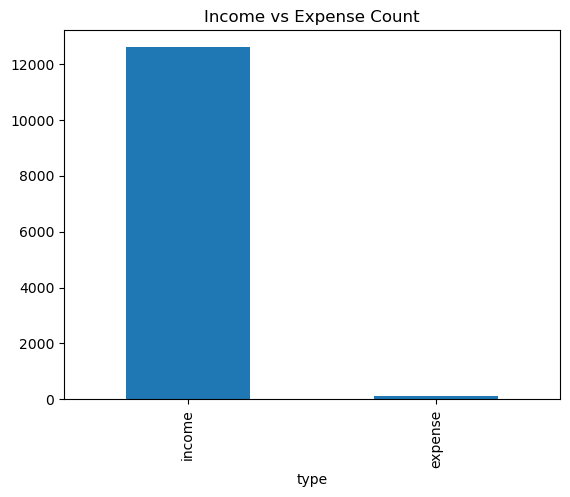

In [19]:
df_combined['type'].value_counts().plot(kind='bar')
plt.title("Income vs Expense Count")
plt.show()

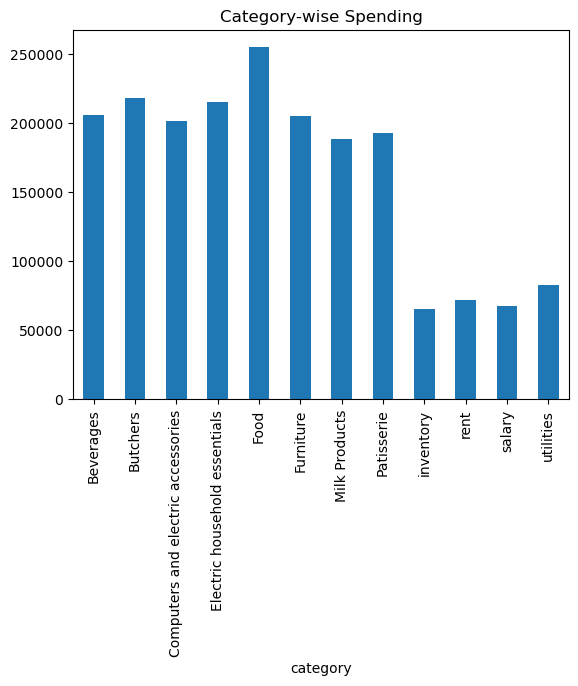

In [20]:
df_combined.groupby('category')['amount'].sum().plot(kind='bar')
plt.title("Category-wise Spending")
# plt.xticks(rotation=45)
plt.show()

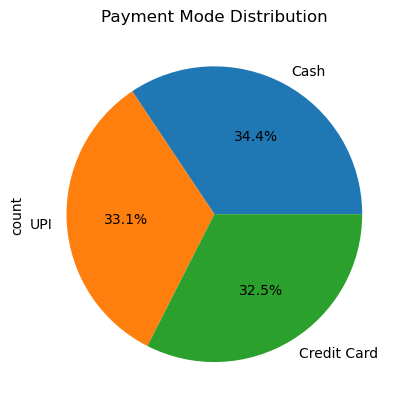

In [21]:
df_combined['payment_mode'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Mode Distribution")
plt.show()

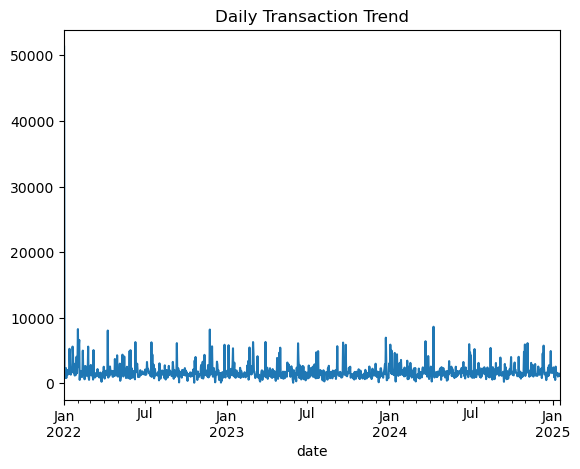

In [22]:
df_combined.groupby('date')['amount'].sum().plot()
plt.title("Daily Transaction Trend")
plt.show()

In [23]:
df_combined["payment_mode"].value_counts()

payment_mode
Cash           4362
UPI            4205
Credit Card    4121
Name: count, dtype: int64

In [24]:
X = df_combined[['amount', 'balance']]

In [25]:
model = IsolationForest(contamination=0.01, random_state=42)

df_combined['anomaly'] = model.fit_predict(X)

In [26]:
df_combined['anomaly'].value_counts()

anomaly
 1    12561
-1      127
Name: count, dtype: int64

In [27]:
df_combined[df_combined['anomaly'] == -1]

,date,amount,type,category,payment_mode,balance,anomaly
6,2022-01-01,350.0,income,Electric household essentials,Cash,10986.5,-1
10,2022-01-01,50000.0,income,Food,UPI,11642.5,-1
18,2022-01-02,380.0,income,Patisserie,Cash,12778.0,-1
47,2022-01-05,395.0,income,Patisserie,Cash,16852.5,-1
69,2022-01-07,369.0,income,Butchers,UPI,19119.5,-1
...,...,...,...,...,...,...,...
12421,2024-12-28,3543.0,expense,salary,Cash,1321444.0,-1
12463,2024-12-31,410.0,income,Butchers,Credit Card,1326701.0,-1
12535,2025-01-04,410.0,income,Furniture,UPI,1336057.0,-1
12561,2025-01-08,380.0,income,Furniture,Cash,1339776.0,-1


In [28]:
df_combined[df_combined['anomaly'] == -1][['date','amount','type','category']].head()

,date,amount,type,category
6,2022-01-01,350.0,income,Electric household essentials
10,2022-01-01,50000.0,income,Food
18,2022-01-02,380.0,income,Patisserie
47,2022-01-05,395.0,income,Patisserie
69,2022-01-07,369.0,income,Butchers


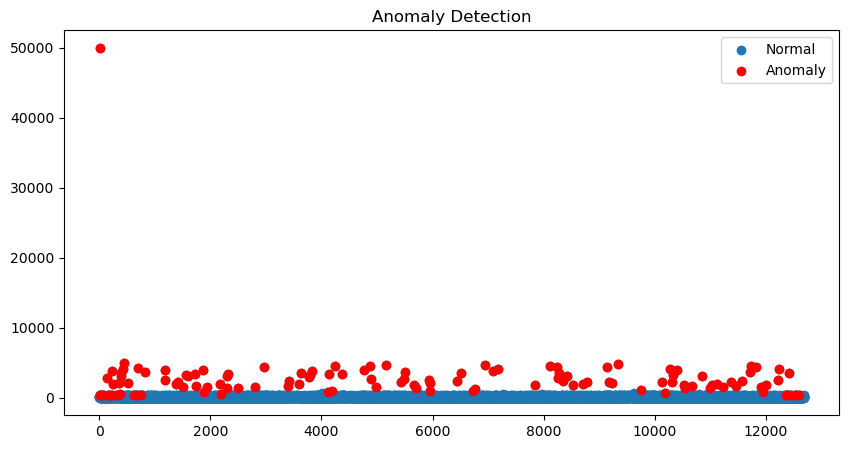

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(df_combined.index, df_combined['amount'], label='Normal')
plt.scatter(df_combined[df_combined['anomaly'] == -1].index,
            df_combined[df_combined['anomaly'] == -1]['amount'],
            color='red', label='Anomaly')

plt.title("Anomaly Detection")
plt.legend()
plt.show()

In [30]:
df_clean = df_combined[df_combined['anomaly'] != -1]

In [31]:
df_income = df_clean[df_clean['type'] == 'income']

In [32]:
df_daily = df_income.groupby('date')['amount'].sum().reset_index()
df_daily = df_daily.sort_values('date')
df_daily['day'] = range(len(df_daily))

In [33]:
X = df_daily[['day']]
y = df_daily['amount']

In [34]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [35]:
future_days = np.array([[len(df_income) + i] for i in range(7)])
forecast = model.predict(future_days)
forecast

C:\Users\sneha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1712.14581802, 1712.16703713, 1712.18825624, 1712.20947534,
       1712.23069445, 1712.25191356, 1712.27313267])

In [36]:
df_daily['rolling_mean'] = df_daily['amount'].rolling(window=7).mean()

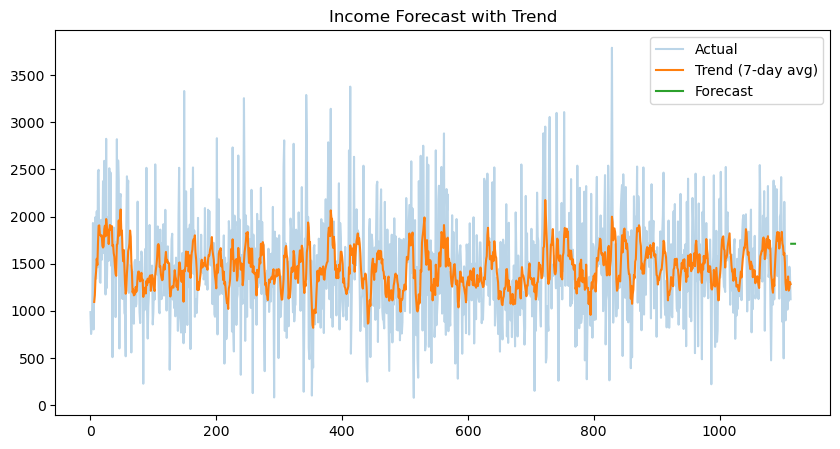

In [37]:
plt.figure(figsize=(10,5))

# Actual noisy data
plt.plot(df_daily['day'], df_daily['amount'], alpha=0.3, label='Actual')

# Smoothed trend (MAIN LINE)
plt.plot(df_daily['day'], df_daily['rolling_mean'], label='Trend (7-day avg)')

# Forecast
plt.plot(range(len(df_daily), len(df_daily)+7), forecast, label='Forecast')

plt.title("Income Forecast with Trend")
plt.legend()
plt.show()

In [38]:
total_income = df_combined[df_combined['type'] == 'income']['amount'].sum()
total_expense = df_combined[df_combined['type'] == 'expense']['amount'].sum()

profit = total_income - total_expense

num_anomalies = df_combined[df_combined['anomaly'] == -1].shape[0]

avg_daily_income = df_daily['amount'].mean()
forecast_avg = forecast.mean()

In [39]:
insights = []

# Profit insight
if profit > 0:
    insights.append("✅ Your business is profitable with a healthy cash flow.")
else:
    insights.append("⚠️ Your business is running at a loss. Review expenses.")

# Expense control
if total_expense < total_income * 0.7:
    insights.append("💰 Expenses are well controlled compared to income.")
else:
    insights.append("⚠️ Expenses are relatively high. Consider cost optimization.")

# Anomaly insight
if num_anomalies > 0:
    insights.append(f"🚨 {num_anomalies} unusual transactions detected. Review them carefully.")

# Forecast insight
if forecast_avg > avg_daily_income:
    insights.append("📈 Revenue is expected to grow in the coming days.")
else:
    insights.append("📊 Revenue is expected to remain stable.")

# Payment behavior insight
payment_mode_counts = df_combined['payment_mode'].value_counts()

if 'UPI' in payment_mode_counts:
    insights.append("💳 Digital payments (UPI) are widely used in your business.")

In [40]:
print("📊 AI Financial Insights:\n")

for i in insights:
    print(i)

📊 AI Financial Insights:

✅ Your business is profitable with a healthy cash flow.
💰 Expenses are well controlled compared to income.
🚨 127 unusual transactions detected. Review them carefully.
📈 Revenue is expected to grow in the coming days.
💳 Digital payments (UPI) are widely used in your business.


In [41]:
!pip install openai

In [43]:
from dotenv import load_dotenv
import os
from openai import OpenAI

load_dotenv()

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [42]:
from openai import OpenAI

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

NameError: name 'os' is not defined

In [ ]:
try:
    ai_output = f"""
The business is profitable with total income of {total_income:.2f} 
and expenses of {total_expense:.2f}.

There are {num_anomalies} unusual transactions detected which should be reviewed.

Revenue is expected to remain stable based on forecasting.

Recommendations:
1. Monitor high-value transactions carefully.
2. Keep expenses under control.
3. Focus on increasing digital payments.
"""
    
    print(ai_output)

except:
    print("⚠️ AI fallback mode\n")
    
    ai_output_fallback = f"""
Basic Insights:

Profit: {profit:.2f}
Anomalies: {num_anomalies}
Forecast Trend: Stable

Recommendation: Monitor expenses and anomalies.
"""
    
    print(ai_output_fallback)